<a href="https://colab.research.google.com/github/LGLV-Ciencia-de-Datos/Curso_python_Ciencia_de_Datos/blob/main/e)_Cross_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Validación cruzada** (Cross-Validation)

Una mejor forma de evaluar tus modelos

En este tutorial, aprenderás cómo utilizar la validación cruzada para obtener mejores medidas del rendimiento del modelo.
###  **Introducción**
El aprendizaje automático es un proceso iterativo.
Te enfrentarás a decisiones sobre qué variables predictoras usar, qué tipos de modelos emplear, qué argumentos proporcionar a esos modelos, etc. Hasta ahora, has tomado estas decisiones de forma basada en datos, midiendo la calidad del modelo con un conjunto de validación (o conjunto de reserva).

Pero existen algunas desventajas en este enfoque. Para entenderlo, imagina que tienes un conjunto de datos con 5000 filas. Normalmente, reservarás aproximadamente el 20% de los datos como conjunto de validación, es decir, unas 1000 filas. Pero esto introduce cierta aleatoriedad en la determinación de las puntuaciones del modelo. Es decir, un modelo puede funcionar bien en un conjunto de 1000 filas, aunque sería inexacto en otro conjunto diferente de 1000 filas.

En un extremo, podrías imaginar tener solo una fila de datos en el conjunto de validación. Si comparas modelos alternativos, cuál de ellos realiza las mejores predicciones en un solo dato será en gran medida cuestión de suerte.

En general, cuanto mayor sea el conjunto de validación, menor será la aleatoriedad (también llamada 'ruido') en nuestra medida de la calidad del modelo, y más fiable será. Por desgracia, solo podemos obtener un conjunto de validación grande eliminando filas de nuestros datos de entrenamiento, y conjuntos de entrenamiento más pequeños implican modelos peores.

### **¿Qué es la validación cruzada?**
En validación cruzada, realizamos nuestro proceso de modelado en diferentes subconjuntos de los datos para obtener múltiples medidas de la calidad del modelo.

Por ejemplo, podríamos comenzar dividiendo los datos en 5 partes, cada una con el 20% del conjunto completo. En este caso, decimos que hemos dividido los datos en 5 'pliegues'.

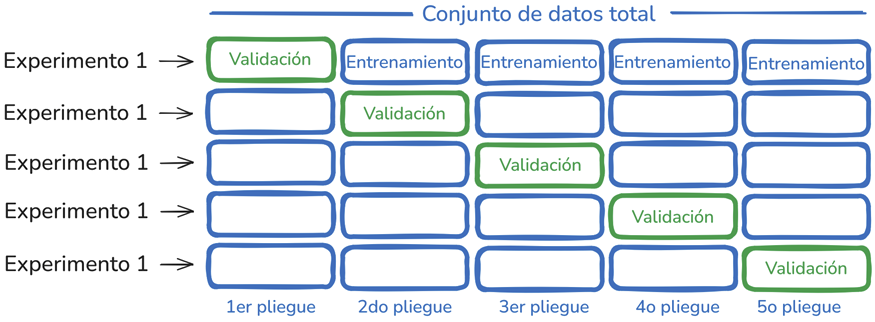

Luego, realizamos un experimento para cada pliegue:
* En el `Experimento 1`, usamos el primer pliegue como conjunto de validación (o de reserva) y todo lo demás como datos de entrenamiento. Esto nos proporciona una medida de la calidad del modelo basada en un conjunto de reserva del 20%.
* En el `Experimento 2`, reservamos datos del segundo pliegue (y usamos todo excepto el segundo pliegue para entrenar el modelo). El conjunto de reserva se utiliza entonces para obtener una segunda estimación de la calidad del modelo.
* Repetimos este proceso, usando cada pliegue una vez como conjunto de reserva.
 Sumando todo, el 100% de los datos se utiliza en algún momento como conjunto de reserva, y al final disponemos de una medida de la calidad del modelo basada en todas las filas del conjunto de datos (aunque no todas se usen simultáneamente).

### **¿Cuándo deberías usar la validación cruzada?**
La validación cruzada proporciona una medida más precisa de la calidad del modelo, lo cual es especialmente importante si tomas muchas decisiones de modelado. Sin embargo, puede tardar más en ejecutarse, ya que estima múltiples modelos (uno por cada pliegue).
Entonces, dadas estas compensaciones, ¿cuándo deberías usar cada enfoque?
* Para conjuntos de datos pequeños, donde la carga computacional adicional no es un problema importante, deberías realizar validación cruzada.
* Para conjuntos de datos más grandes, un único conjunto de validación es suficiente. Tu código se ejecutará más rápido y puede que tengas suficientes datos como para no necesitar reutilizar parte de ellos para la validación.

No existe un umbral simple que defina qué constituye un conjunto de datos grande o pequeño. Pero si tu modelo tarda un par de minutos o menos en ejecutarse, probablemente valga la pena cambiar a validación cruzada.

Alternativamente, puedes realizar validación cruzada y comprobar si las puntuaciones de cada experimento parecen cercanas. Si cada experimento arroja resultados similares, un único conjunto de validación probablemente sea suficiente.

### **Ejemplo**
Trabajaremos con los mismos datos que en el tutorial anterior. Cargamos los datos de entrada en X y los datos de salida en y.

In [ ]:
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")

print("Path to dataset files:", path)

# Load the data into a pandas DataFrame
melbourne_file_path = path + '/melb_data.csv'
melbourne_data = pd.read_csv(melbourne_file_path)

# Print the first 5 rows of the DataFrame
display(melbourne_data.shape)

# Select subset of predictors
cols_to_use = ['Rooms', 'Distance', 'Landsize', 'BuildingArea', 'YearBuilt']
X = melbourne_data[cols_to_use]

# Select target
y = melbourne_data.Price

In [ ]:
# Select subset of predictors
cols_to_use = ['Rooms', 'Distance', 'Landsize', 'BuildingArea', 'YearBuilt']
X = melbourne_data[cols_to_use]

# Select target
y = melbourne_data.Price

Luego, definimos un `pipeline` que utiliza un imputador para rellenar los valores faltantes y un modelo de bosque aleatorio `random forest model` para hacer predicciones. Aunque es posible realizar validación cruzada `cross-validation` sin `pipelines`, ¡es bastante difícil! Utilizar un `pipeline` hará que el código sea notablemente más sencillo.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

my_pipeline = Pipeline(steps=[('preprocessor', SimpleImputer()),
                              ('model', RandomForestRegressor(n_estimators=50,
                                                              random_state=0))
                             ])

Obtenemos las puntuaciones de validación cruzada con la función [cross_val_score()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) de `scikit-learn`. Establecemos el número de pliegues con el parámetro `cv`.

In [ ]:
# Importa la función 'cross_val_score' del módulo 'sklearn.model_selection'.
# Esta función es la que realiza la validación cruzada.
from sklearn.model_selection import cross_val_score

# Se definen las variables 'X' y 'y', que representan los datos de entrada (características)
# y la variable objetivo que el modelo debe predecir, respectivamente.
# 'my_pipeline' es una secuencia de transformaciones y el modelo final.
# La función 'cross_val_score' evalúa el rendimiento de 'my_pipeline'.
# 'cv=5' indica que la validación cruzada se realizará con 5 pliegues (folds).
# 'scoring='neg_mean_absolute_error'' especifica que la métrica de evaluación será el
# error absoluto medio negativo (Negative Mean Absolute Error).
scores = cross_val_score(my_pipeline, X, y,
                              cv=5,
                              scoring='neg_mean_absolute_error')

# Se multiplican los puntajes (scores) por -1. Esto es necesario porque 'sklearn'
# por convención, devuelve el 'neg_mean_absolute_error', que es el valor negativo
# del error absoluto medio (MAE). Al multiplicarlo por -1, se obtiene el MAE positivo.
scores = -1 * scores

# Se imprimen los puntajes MAE (Error Absoluto Medio) para cada uno de los 5 pliegues.
# Estos valores muestran qué tan bien se desempeñó el modelo en cada una de las 5
# divisiones de los datos.
print("MAE scores:\n", scores)

In [ ]:
from sklearn.model_selection import cross_val_score

# Multiply by -1 since sklearn calculates *negative* MAE
scores = -1 * cross_val_score(my_pipeline, X, y,
                              cv=5,
                              scoring='neg_mean_absolute_error')

print("MAE scores:\n", scores)

El parámetro de puntuación elige una medida de calidad del modelo a reportar: en este caso, optamos por el error absoluto medio negativo (MAE). La documentación de `scikit-learn` muestra una [lista de opciones](https://scikit-learn.org/stable/modules/model_evaluation.html).

Resulta un poco sorprendente que especifiquemos el MAE negativo. Scikit-learn tiene una convención en la que todas las métricas se definen de modo que un número alto sea mejor. Utilizar valores negativos aquí permite mantener esa convención, aunque el MAE negativo es casi desconocido en otros contextos.

Normalmente, queremos una única medida de calidad del modelo para comparar modelos alternativos. Por eso, calculamos la media en todos los experimentos.

In [ ]:
print("Average MAE score (across experiments):")
print(scores.mean())

### **Conclusión**
El uso de la validación cruzada proporciona una medida mucho más precisa de la calidad del modelo, además de simplificar nuestro código: cabe destacar que ya no es necesario mantener conjuntos de entrenamiento y validación por separado. Por ello, especialmente en conjuntos de datos pequeños, es una mejora significativa.